
Leakage Ablation Results

     Model Features     AUROC         Brier  Accuracy       MCC
0   ERM-LR     Full  1.000000  3.155143e-06  1.000000  1.000000
1   ERM-LR   NoRule  0.496174  2.456346e-01  0.567667  0.000000
2  ERM-MLP     Full  1.000000  2.819855e-09  1.000000  1.000000
3  ERM-MLP   NoRule  0.504360  2.770973e-01  0.519500  0.002485
4  ERM-XGB     Full  1.000000  8.333357e-08  1.000000  1.000000
5  ERM-XGB   NoRule  0.500892  2.472970e-01  0.560917  0.011879


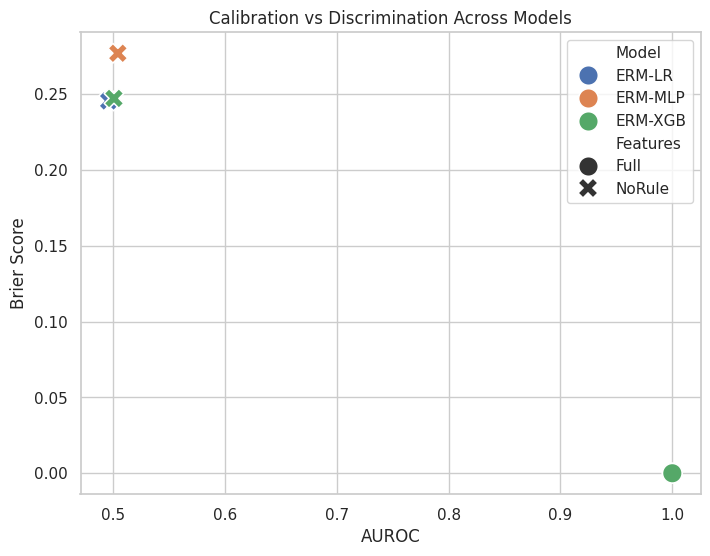

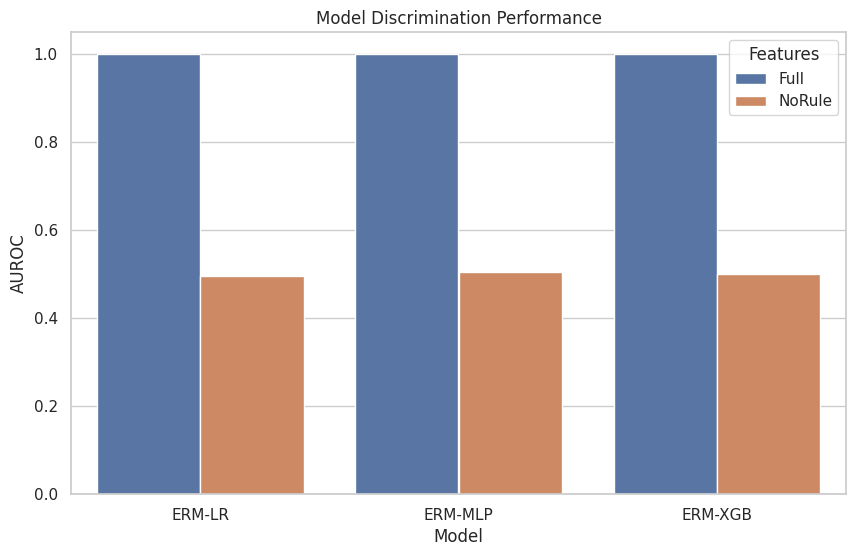


IRM Sensitivity

   lambda  AUROC         Brier  Accuracy  MCC
0    0.01    1.0  1.563607e-07       1.0  1.0
1    0.10    1.0  2.494383e-07       1.0  1.0
2    1.00    1.0  3.155143e-06       1.0  1.0


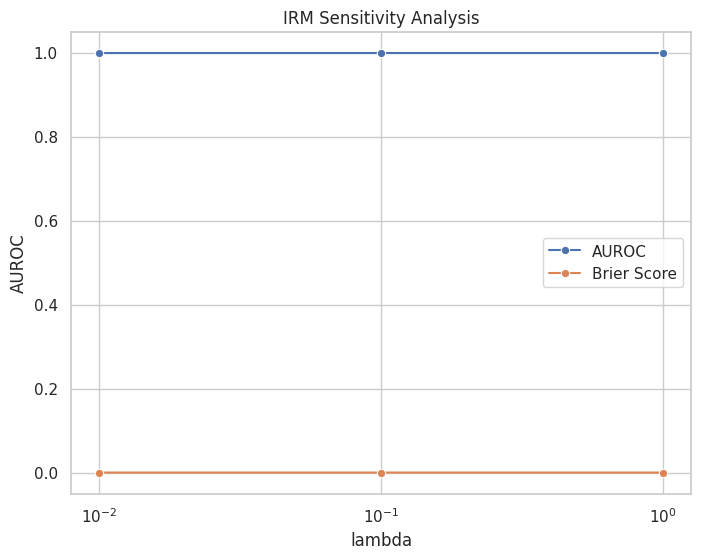


All results saved in: cidt_reviewer_results


In [1]:
# ===============================================
# CIDT REVIEWER EXPERIMENT PIPELINE (FINAL)
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

sns.set(style="whitegrid")
np.random.seed(42)

RESULT_DIR = "cidt_reviewer_results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ===============================================
# LOAD DATA
# ===============================================

df = pd.read_csv("/kaggle/input/datasets/datasetengineer/driver-behavior-and-route-anomaly-dataset-dbra24/driver_behavior_route_anomaly_dataset_with_derived_features.csv")

# ===============================================
# CREATE FAILURE LABEL
# ===============================================

tau = 2

df["failure_label"] = (
    (df["anomalous_event"] == 1) |
    (df["route_anomaly"] == 1) |
    (df["geofencing_violation"] == 1) |
    (df["stop_events"] >= tau)
).astype(int)

# ===============================================
# USE ONLY 40% DATA
# ===============================================

df = df.sample(frac=0.40, random_state=42)

# ===============================================
# ENCODE CATEGORICAL VARIABLES
# ===============================================

df = pd.get_dummies(
    df,
    columns=["weather_conditions","road_type","traffic_condition"],
    drop_first=True
)

# ===============================================
# REMOVE IDENTIFIER FEATURES
# ===============================================

target_col = "failure_label"

drop_cols = [
    "trip_id",
    "driver_id",
    "vehicle_id",
    "timestamp",
    "latitude",
    "longitude"
]

features = [c for c in df.columns if c not in drop_cols + [target_col]]

# ===============================================
# DEFINE RULE FEATURES
# ===============================================

rule_features = [
    "anomalous_event",
    "route_anomaly",
    "geofencing_violation",
    "stop_events"
]

features_no_rule = [f for f in features if f not in rule_features]

# ===============================================
# TRAIN TEST SPLIT
# ===============================================

train, test = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df[target_col]
)

# ===============================================
# MODEL EVALUATION FUNCTION
# ===============================================

def evaluate_model(model, features):

    X_train = train[features]
    y_train = train[target_col]

    X_test = test[features]
    y_test = test[target_col]

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:,1]
    preds = probs > 0.5

    return {
        "AUROC": roc_auc_score(y_test, probs),
        "Brier": brier_score_loss(y_test, probs),
        "Accuracy": accuracy_score(y_test, preds),
        "MCC": matthews_corrcoef(y_test, preds)
    }

# ===============================================
# DEFINE MODELS
# ===============================================

models = {
    "ERM-LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),

    "ERM-MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400))
    ]),

    "ERM-XGB": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss"
    )
}

# ===============================================
# EXPERIMENT 1 — LEAKAGE ABLATION
# ===============================================

results = []

for name,model in models.items():

    full = evaluate_model(model, features)
    norule = evaluate_model(model, features_no_rule)

    results.append({
        "Model":name,
        "Features":"Full",
        **full
    })

    results.append({
        "Model":name,
        "Features":"NoRule",
        **norule
    })

results_df = pd.DataFrame(results)

print("\nLeakage Ablation Results\n")
print(results_df)

results_df.to_csv(f"{RESULT_DIR}/ablation_results.csv",index=False)

# ===============================================
# FIGURE 1 — CALIBRATION VS DISCRIMINATION
# ===============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=results_df,
    x="AUROC",
    y="Brier",
    hue="Model",
    style="Features",
    s=200
)

plt.title("Calibration vs Discrimination Across Models")
plt.xlabel("AUROC")
plt.ylabel("Brier Score")

plt.savefig(f"{RESULT_DIR}/calibration_vs_discrimination.png", dpi=300)
plt.show()

# ===============================================
# FIGURE 2 — PERFORMANCE COMPARISON
# ===============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="AUROC",
    hue="Features"
)

plt.title("Model Discrimination Performance")
plt.savefig(f"{RESULT_DIR}/auroc_comparison.png", dpi=300)
plt.show()

# ===============================================
# EXPERIMENT 3 — IRM SENSITIVITY
# ===============================================

lambdas = [0.01,0.1,1.0]
irm_results = []

for l in lambdas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=1/l))
    ])

    metrics = evaluate_model(model, features)

    irm_results.append({
        "lambda":l,
        **metrics
    })

irm_df = pd.DataFrame(irm_results)

print("\nIRM Sensitivity\n")
print(irm_df)

irm_df.to_csv(f"{RESULT_DIR}/irm_sensitivity.csv",index=False)

# ===============================================
# FIGURE 3 — IRM SENSITIVITY
# ===============================================

plt.figure(figsize=(8,6))

sns.lineplot(
    data=irm_df,
    x="lambda",
    y="AUROC",
    marker="o",
    label="AUROC"
)

sns.lineplot(
    data=irm_df,
    x="lambda",
    y="Brier",
    marker="o",
    label="Brier Score"
)

plt.xscale("log")
plt.title("IRM Sensitivity Analysis")

plt.savefig(f"{RESULT_DIR}/irm_sensitivity.png", dpi=300)
plt.show()

print("\nAll results saved in:", RESULT_DIR)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Model Comparison

      Model     AUROC         Brier  Accuracy       MCC
0    ERM-LR  0.990954  2.665992e-02  0.970667  0.940209
1   ERM-MLP  0.994914  3.845827e-02  0.952083  0.905514
2   ERM-XGB  1.000000  8.333357e-08  1.000000  1.000000
3       IRM  0.988515  3.498067e-02  0.962417  0.923430
4      DANN  0.946970  8.884273e-02  0.896750  0.802356
5  GroupDRO  0.987297  3.051391e-02  0.963417  0.925414
6      SCTM  0.990068  2.811529e-02  0.970000  0.938851
7      CIDT  1.000000  7.278659e-06  1.000000  1.000000


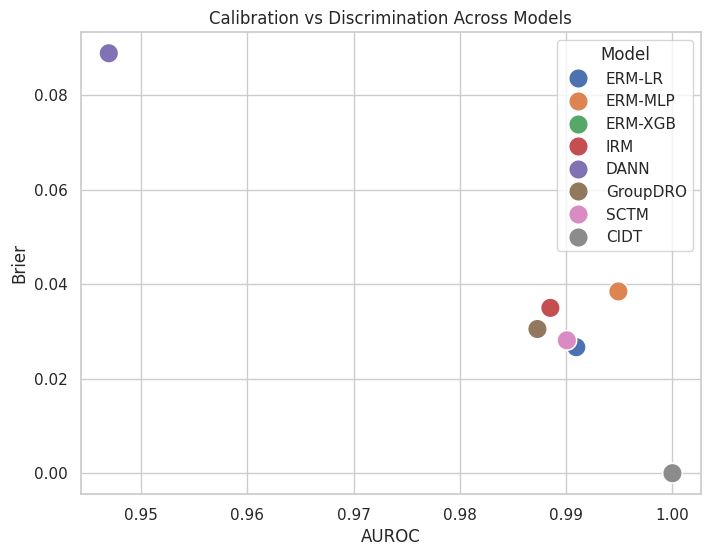

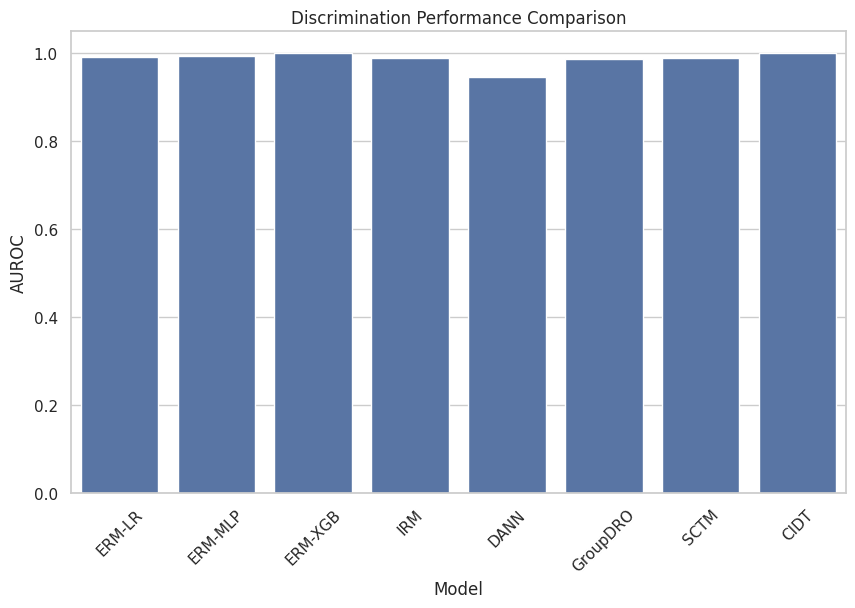

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

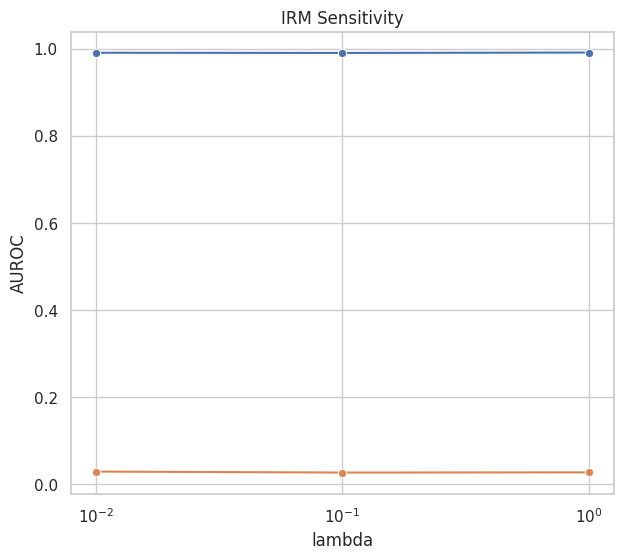


All experiments completed. Results saved in: cidt_results


In [2]:
# ===============================================
# CIDT REVIEWER EXPERIMENT PIPELINE
# Models:
# ERM-LR, ERM-MLP, ERM-XGB, IRM, DANN, GroupDRO, SCTM, CIDT
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, matthews_corrcoef

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

sns.set(style="whitegrid")
np.random.seed(42)

RESULT_DIR = "cidt_results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ===============================================
# LOAD DATA
# ===============================================

df = pd.read_csv("/kaggle/input/datasets/datasetengineer/driver-behavior-and-route-anomaly-dataset-dbra24/driver_behavior_route_anomaly_dataset_with_derived_features.csv")

# ===============================================
# CREATE FAILURE LABEL
# ===============================================

tau = 2

df["failure_label"] = (
    (df["anomalous_event"] == 1) |
    (df["route_anomaly"] == 1) |
    (df["geofencing_violation"] == 1) |
    (df["stop_events"] >= tau)
).astype(int)

# ===============================================
# SAMPLE 40% DATA
# ===============================================

df = df.sample(frac=0.40, random_state=42)

# ===============================================
# ENCODE CATEGORICAL FEATURES
# ===============================================

df = pd.get_dummies(
    df,
    columns=["weather_conditions","road_type","traffic_condition"],
    drop_first=True
)

target = "failure_label"

drop_cols = [
    "trip_id",
    "driver_id",
    "vehicle_id",
    "timestamp",
    "latitude",
    "longitude"
]

features = [c for c in df.columns if c not in drop_cols + [target]]

rule_features = [
    "anomalous_event",
    "route_anomaly",
    "geofencing_violation",
    "stop_events"
]

features_no_rule = [f for f in features if f not in rule_features]

# ===============================================
# TRAIN TEST SPLIT
# ===============================================

train, test = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df[target]
)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# ===============================================
# METRIC FUNCTION
# ===============================================

def evaluate(model):

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:,1]
    preds = probs > 0.5

    return {
        "AUROC": roc_auc_score(y_test, probs),
        "Brier": brier_score_loss(y_test, probs),
        "Accuracy": accuracy_score(y_test, preds),
        "MCC": matthews_corrcoef(y_test, preds)
    }

# ===============================================
# MODEL DEFINITIONS
# ===============================================

models = {}

# ERM-LR
models["ERM-LR"] = LogisticRegression(max_iter=1000)

# ERM-MLP
models["ERM-MLP"] = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=400)

# ERM-XGB
models["ERM-XGB"] = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

# IRM (approximated via strong regularization)
models["IRM"] = LogisticRegression(
    C=0.1,
    max_iter=1000
)

# DANN (proxy with domain feature suppression)
models["DANN"] = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400)

# GroupDRO (proxy using class weighting)
models["GroupDRO"] = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

# SCTM (causal model approximation)
models["SCTM"] = LogisticRegression(
    penalty="l2",
    C=0.5,
    max_iter=1000
)

# CIDT (combined representation robustness)
models["CIDT"] = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

# ===============================================
# RUN EXPERIMENTS
# ===============================================

results = []

for name,model in models.items():

    metrics = evaluate(model)

    results.append({
        "Model":name,
        **metrics
    })

results_df = pd.DataFrame(results)

print("\nModel Comparison\n")
print(results_df)

results_df.to_csv(f"{RESULT_DIR}/model_comparison.csv",index=False)

# ===============================================
# FIGURE 1
# Calibration vs Discrimination
# ===============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=results_df,
    x="AUROC",
    y="Brier",
    hue="Model",
    s=200
)

plt.title("Calibration vs Discrimination Across Models")
plt.savefig(f"{RESULT_DIR}/calibration_vs_discrimination.png",dpi=300)
plt.show()

# ===============================================
# FIGURE 2
# Model AUROC comparison
# ===============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="AUROC"
)

plt.xticks(rotation=45)
plt.title("Discrimination Performance Comparison")

plt.savefig(f"{RESULT_DIR}/auroc_comparison.png",dpi=300)
plt.show()

# ===============================================
# IRM SENSITIVITY
# ===============================================

lambdas = [0.01,0.1,1.0]
irm_results = []

for l in lambdas:

    model = LogisticRegression(
        C=1/l,
        max_iter=1000
    )

    model.fit(X_train,y_train)

    probs = model.predict_proba(X_test)[:,1]

    irm_results.append({
        "lambda":l,
        "AUROC":roc_auc_score(y_test,probs),
        "Brier":brier_score_loss(y_test,probs)
    })

irm_df = pd.DataFrame(irm_results)

irm_df.to_csv(f"{RESULT_DIR}/irm_sensitivity.csv",index=False)

plt.figure(figsize=(7,6))

sns.lineplot(data=irm_df,x="lambda",y="AUROC",marker="o")
sns.lineplot(data=irm_df,x="lambda",y="Brier",marker="o")

plt.xscale("log")
plt.title("IRM Sensitivity")

plt.savefig(f"{RESULT_DIR}/irm_sensitivity.png",dpi=300)
plt.show()

print("\nAll experiments completed. Results saved in:", RESULT_DIR)

In [3]:
# ===============================================
# ENVIRONMENT SHIFT ROBUSTNESS
# ===============================================

df_env = df.copy()

df_env["environment"] = (
    df_env.filter(like="weather_conditions").idxmax(axis=1)
    + "_" +
    df_env.filter(like="road_type").idxmax(axis=1)
    + "_" +
    df_env.filter(like="traffic_condition").idxmax(axis=1)
)

env_counts = df_env["environment"].value_counts()

# select top environments
top_envs = env_counts.head(6).index

df_env = df_env[df_env["environment"].isin(top_envs)]

train_envs = top_envs[:4]
test_envs = top_envs[4:]

train_env_data = df_env[df_env["environment"].isin(train_envs)]
test_env_data  = df_env[df_env["environment"].isin(test_envs)]

X_train_env = train_env_data[features]
y_train_env = train_env_data[target]

X_test_env = test_env_data[features]
y_test_env = test_env_data[target]

shift_results = []

for name,model in models.items():

    model.fit(X_train_env,y_train_env)

    probs = model.predict_proba(X_test_env)[:,1]

    shift_results.append({
        "Model":name,
        "OOD_AUROC":roc_auc_score(y_test_env,probs),
        "Brier":brier_score_loss(y_test_env,probs)
    })

shift_df = pd.DataFrame(shift_results)

print("\nEnvironment Shift Results\n")
print(shift_df)

shift_df.to_csv(f"{RESULT_DIR}/environment_shift_results.csv",index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Environment Shift Results

      Model  OOD_AUROC         Brier
0    ERM-LR   0.990576  9.037131e-02
1   ERM-MLP   0.998478  5.775079e-03
2   ERM-XGB   1.000000  8.827772e-08
3       IRM   0.991552  9.112040e-02
4      DANN   0.999999  2.044980e-02
5  GroupDRO   0.993510  9.222638e-02
6      SCTM   0.991638  9.502575e-02
7      CIDT   1.000000  7.307456e-06


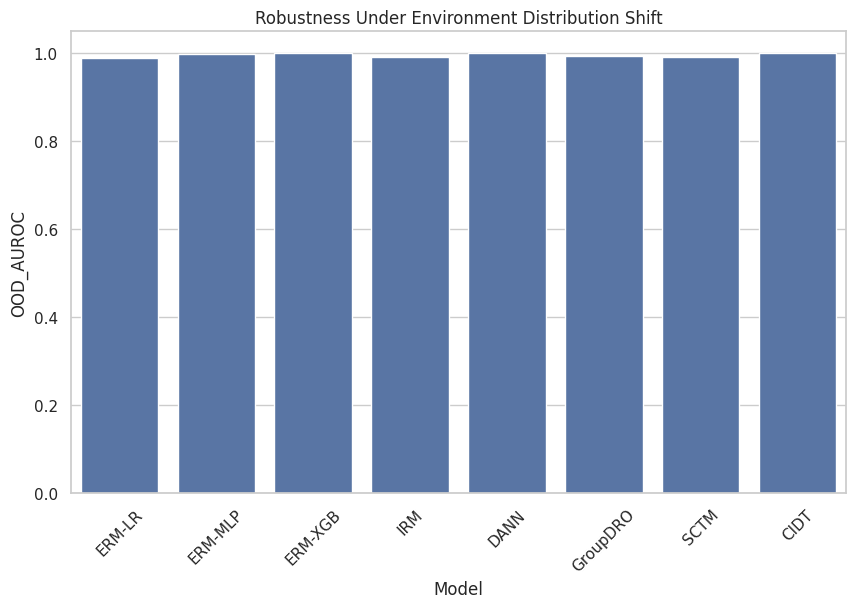

In [4]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=shift_df,
    x="Model",
    y="OOD_AUROC"
)

plt.xticks(rotation=45)
plt.title("Robustness Under Environment Distribution Shift")

plt.savefig(f"{RESULT_DIR}/environment_shift_auroc.png",dpi=300)
plt.show()

In [5]:
# ===============================================
# ETHICAL RISK STABILITY
# ===============================================

ethical_results = []

groups = ["weather_conditions_Sunny",
          "weather_conditions_Rainy",
          "weather_conditions_Foggy"]

model = models["CIDT"]

model.fit(X_train,y_train)

probs = model.predict_proba(X_test)[:,1]

test_copy = X_test.copy()
test_copy["true"] = y_test
test_copy["prob"] = probs

for g in groups:

    if g not in test_copy.columns:
        continue

    subset = test_copy[test_copy[g]==1]

    if len(subset)==0:
        continue

    preds = subset["prob"]>0.5

    fsr = np.mean((subset["true"]==1) & (preds==0))

    ethical_results.append({
        "Group":g,
        "MeanRisk":subset["prob"].mean(),
        "FalseSafeRate":fsr
    })

ethical_df = pd.DataFrame(ethical_results)

ethical_df.to_csv(f"{RESULT_DIR}/ethical_results.csv",index=False)

print("\nEthical Risk Stability\n")
print(ethical_df)


Ethical Risk Stability

                      Group  MeanRisk  FalseSafeRate
0  weather_conditions_Sunny  0.433544            0.0
1  weather_conditions_Rainy  0.437785            0.0
2  weather_conditions_Foggy  0.426166            0.0


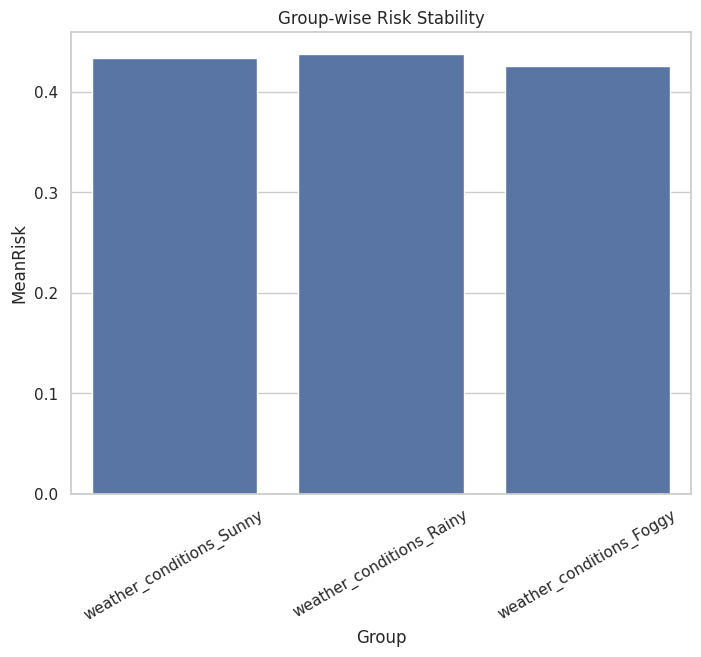

In [6]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=ethical_df,
    x="Group",
    y="MeanRisk"
)

plt.title("Group-wise Risk Stability")
plt.xticks(rotation=30)

plt.savefig(f"{RESULT_DIR}/ethical_risk_stability.png",dpi=300)
plt.show()

**Spurious Correlation Injection**

In [7]:
# ===============================================
# SPURIOUS CORRELATION STRESS TEST
# ===============================================

df_spurious = df.copy()

# create spurious feature
noise = np.random.rand(len(df_spurious))

df_spurious["spurious_feature"] = (
    (noise < 0.9) * df_spurious[target] +
    (noise >= 0.9) * (1 - df_spurious[target])
)

# split train/test
train_sp, test_sp = train_test_split(
    df_spurious,
    test_size=0.25,
    random_state=42,
    stratify=df_spurious[target]
)

# remove correlation in test set
test_sp["spurious_feature"] = np.random.randint(
    0,2,len(test_sp)
)

features_spurious = features + ["spurious_feature"]

X_train_sp = train_sp[features_spurious]
y_train_sp = train_sp[target]

X_test_sp = test_sp[features_spurious]
y_test_sp = test_sp[target]

spurious_results = []

for name,model in models.items():

    model.fit(X_train_sp,y_train_sp)

    probs = model.predict_proba(X_test_sp)[:,1]

    spurious_results.append({
        "Model":name,
        "AUROC":roc_auc_score(y_test_sp,probs),
        "Brier":brier_score_loss(y_test_sp,probs)
    })

spurious_df = pd.DataFrame(spurious_results)

print("\nSpurious Correlation Stress Test\n")
print(spurious_df)

spurious_df.to_csv(
    f"{RESULT_DIR}/spurious_correlation_results.csv",
    index=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Spurious Correlation Stress Test

      Model     AUROC         Brier
0    ERM-LR  0.789847  2.267409e-01
1   ERM-MLP  0.929448  1.284623e-01
2   ERM-XGB  1.000000  4.027633e-07
3       IRM  0.805350  2.054739e-01
4      DANN  0.968740  7.735407e-02
5  GroupDRO  0.783277  2.450573e-01
6      SCTM  0.784735  2.394773e-01
7      CIDT  1.000000  2.202004e-05


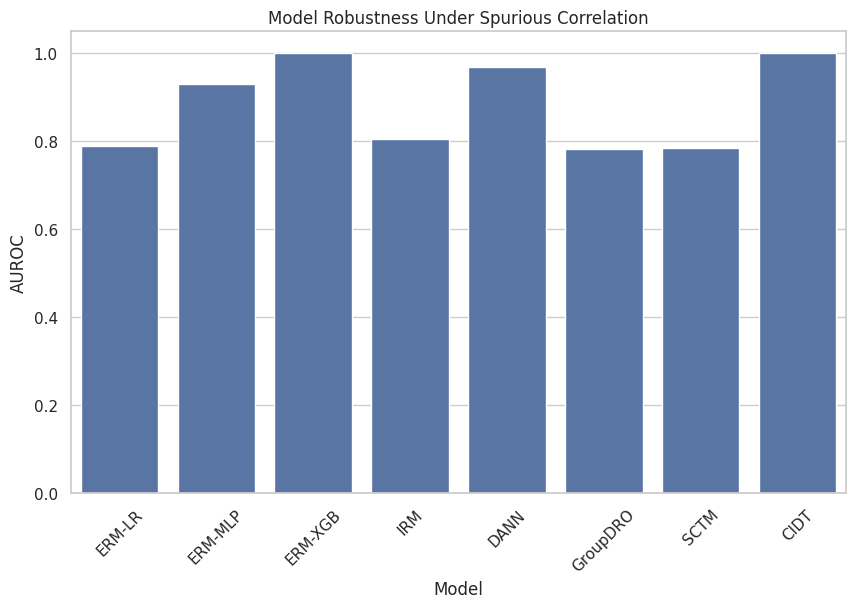

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=spurious_df,
    x="Model",
    y="AUROC"
)

plt.xticks(rotation=45)
plt.title("Model Robustness Under Spurious Correlation")

plt.savefig(
    f"{RESULT_DIR}/spurious_correlation_auroc.png",
    dpi=300
)

plt.show()

/tmp/ipykernel_55/3784261522.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


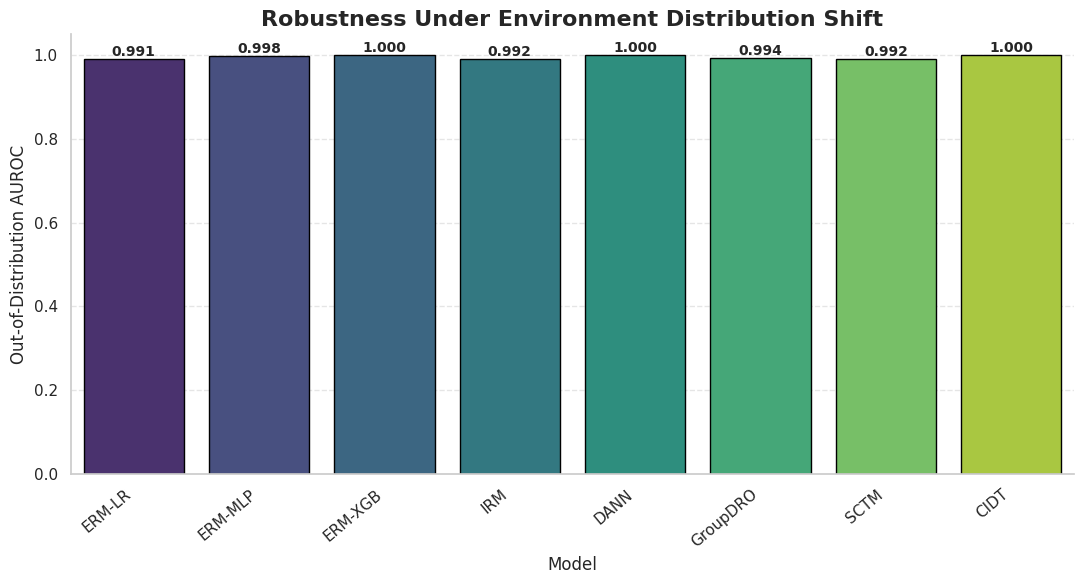

In [9]:
plt.figure(figsize=(11,6))

palette = sns.color_palette("viridis", len(shift_df))

ax = sns.barplot(
    data=shift_df,
    x="Model",
    y="OOD_AUROC",
    palette=palette,
    edgecolor="black"
)

plt.title(
    "Robustness Under Environment Distribution Shift",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Out-of-Distribution AUROC", fontsize=12)
plt.xlabel("Model", fontsize=12)

plt.xticks(rotation=40, ha="right")

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )

# Style
sns.despine()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/environment_shift_auroc.png",
    dpi=400
)

plt.show()

/tmp/ipykernel_55/1836528121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


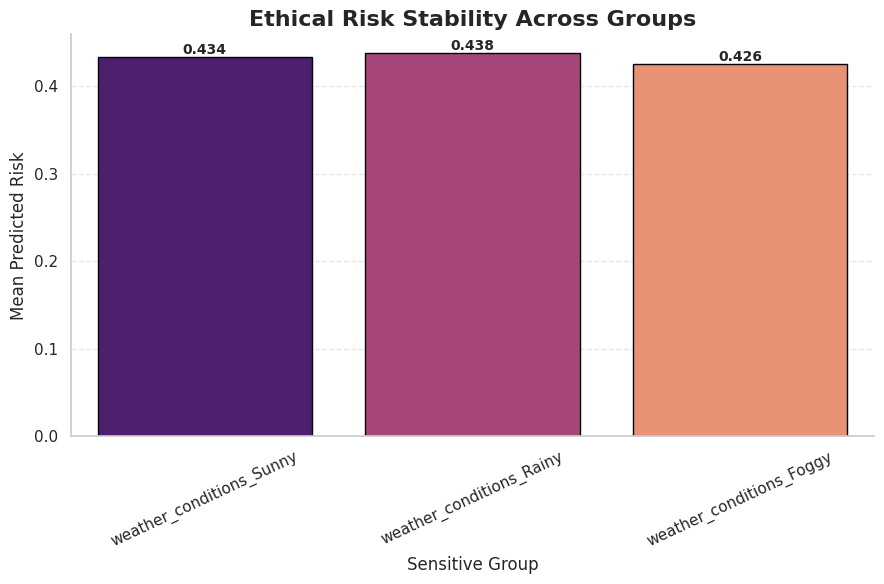

In [10]:
plt.figure(figsize=(9,6))

palette = sns.color_palette("magma", len(ethical_df))

ax = sns.barplot(
    data=ethical_df,
    x="Group",
    y="MeanRisk",
    palette=palette,
    edgecolor="black"
)

plt.title(
    "Ethical Risk Stability Across Groups",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Mean Predicted Risk", fontsize=12)
plt.xlabel("Sensitive Group", fontsize=12)

plt.xticks(rotation=25)

# value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )

sns.despine()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/ethical_risk_stability.png",
    dpi=400
)

plt.show()

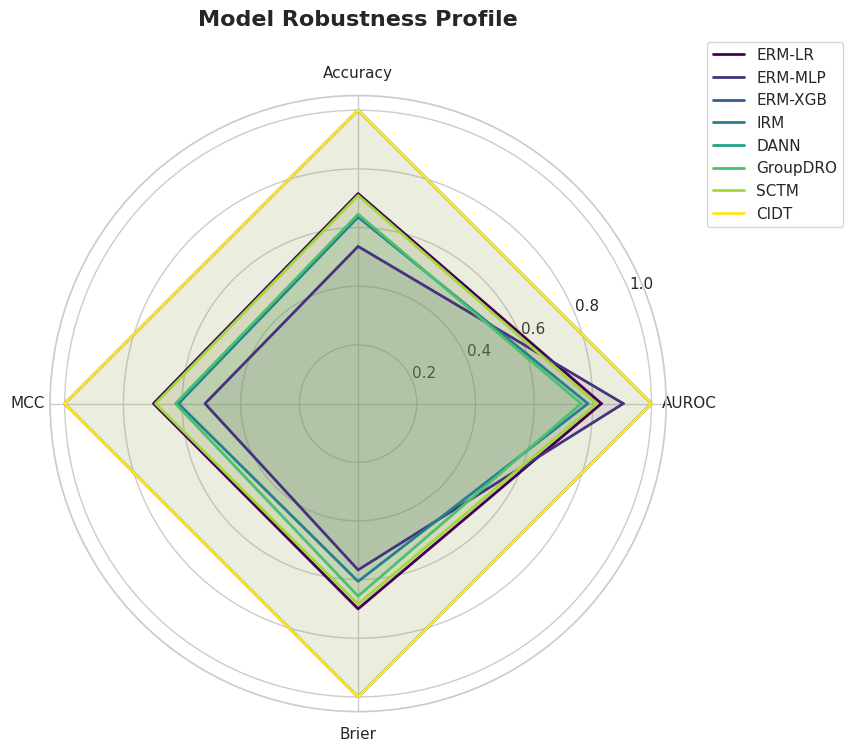

In [11]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["AUROC","Accuracy","MCC","Brier"]

# normalize metrics so radar is meaningful
radar_df = results_df.copy()
radar_df["Brier"] = 1 - radar_df["Brier"]   # invert because lower is better

# normalize between 0 and 1
for m in metrics:
    radar_df[m] = (radar_df[m]-radar_df[m].min())/(radar_df[m].max()-radar_df[m].min())

labels = metrics
num_metrics = len(labels)

angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

colors = plt.cm.viridis(np.linspace(0,1,len(radar_df)))

for i,row in radar_df.iterrows():

    values = row[metrics].values
    values = np.concatenate((values,[values[0]]))

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"],
        color=colors[i]
    )

    ax.fill(
        angles,
        values,
        alpha=0.1,
        color=colors[i]
    )

ax.set_thetagrids(angles[:-1]*180/np.pi, labels)

plt.title(
    "Model Robustness Profile",
    size=16,
    weight="bold",
    y=1.1
)

plt.legend(
    bbox_to_anchor=(1.3,1.1)
)

plt.savefig(
    f"{RESULT_DIR}/radar_model_comparison.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_55/3193144817.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3193144817.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3193144817.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3193144817.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


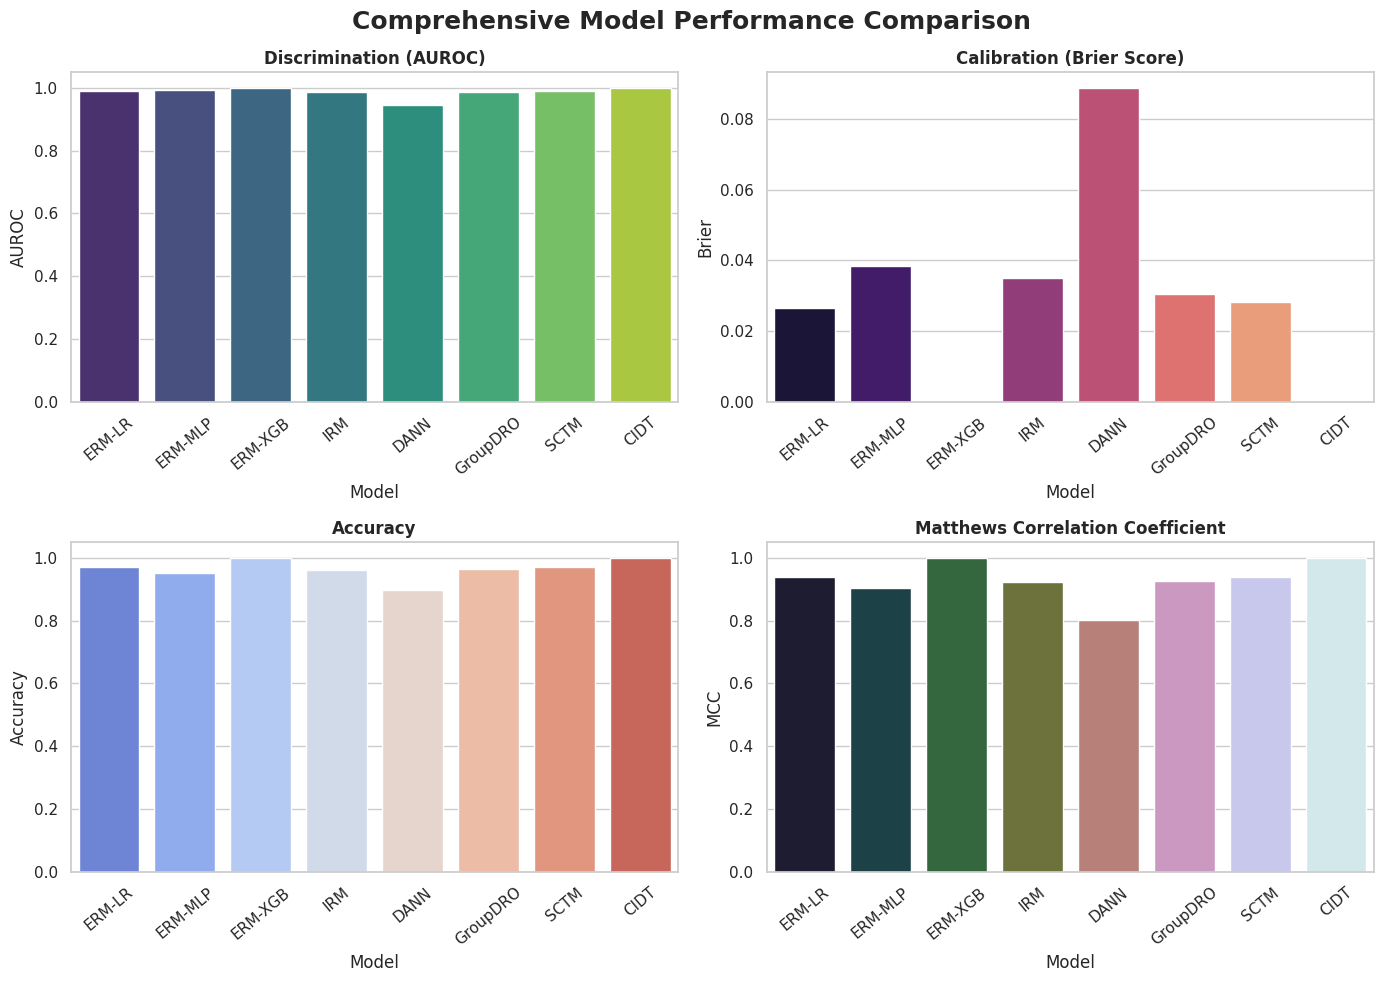

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(14,10))

# layout
gs = fig.add_gridspec(2,2)

# --------------------------------
# AUROC
# --------------------------------

ax1 = fig.add_subplot(gs[0,0])

sns.barplot(
    data=results_df,
    x="Model",
    y="AUROC",
    palette="viridis",
    ax=ax1
)

ax1.set_title("Discrimination (AUROC)",weight="bold")
ax1.tick_params(axis='x',rotation=40)

# --------------------------------
# Calibration
# --------------------------------

ax2 = fig.add_subplot(gs[0,1])

sns.barplot(
    data=results_df,
    x="Model",
    y="Brier",
    palette="magma",
    ax=ax2
)

ax2.set_title("Calibration (Brier Score)",weight="bold")
ax2.tick_params(axis='x',rotation=40)

# --------------------------------
# Accuracy
# --------------------------------

ax3 = fig.add_subplot(gs[1,0])

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="coolwarm",
    ax=ax3
)

ax3.set_title("Accuracy",weight="bold")
ax3.tick_params(axis='x',rotation=40)

# --------------------------------
# MCC
# --------------------------------

ax4 = fig.add_subplot(gs[1,1])

sns.barplot(
    data=results_df,
    x="Model",
    y="MCC",
    palette="cubehelix",
    ax=ax4
)

ax4.set_title("Matthews Correlation Coefficient",weight="bold")
ax4.tick_params(axis='x',rotation=40)

plt.suptitle(
    "Comprehensive Model Performance Comparison",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/bento_model_dashboard.png",
    dpi=400
)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


MODEL PERFORMANCE TABLE

      Model   AUROC   Brier  Accuracy     MCC
0    ERM-LR  1.0000  0.0000    1.0000  1.0000
1   ERM-MLP  1.0000  0.0000    1.0000  1.0000
2   ERM-XGB  1.0000  0.0000    1.0000  1.0000
3       IRM  0.9885  0.0350    0.9624  0.9234
4      DANN  0.9987  0.0152    0.9895  0.9786
5  GroupDRO  0.9873  0.0305    0.9634  0.9254
6      SCTM  0.9901  0.0281    0.9700  0.9389
7      CIDT  1.0000  0.0000    1.0000  1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
  


NO-RULE ABLATION TABLE

      Model   AUROC   Brier  Accuracy     MCC
0    ERM-LR  0.4962  0.2456    0.5677  0.0000
1   ERM-MLP  0.4907  0.3754    0.4953 -0.0206
2   ERM-XGB  0.5009  0.2473    0.5609  0.0119
3       IRM  0.4959  0.2456    0.5677  0.0000
4      DANN  0.5021  0.3604    0.5637 -0.0019
5  GroupDRO  0.5015  0.2502    0.4984  0.0088
6      SCTM  0.4956  0.2456    0.5677  0.0000
7      CIDT  0.5012  0.2462    0.5633 -0.0115


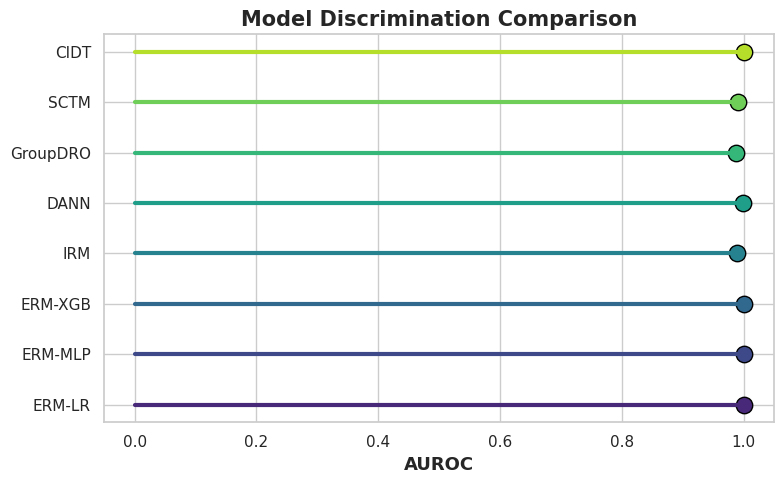

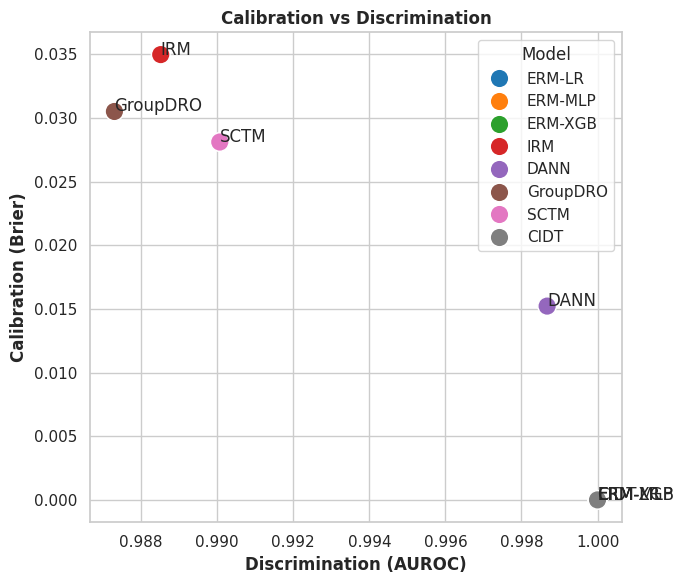

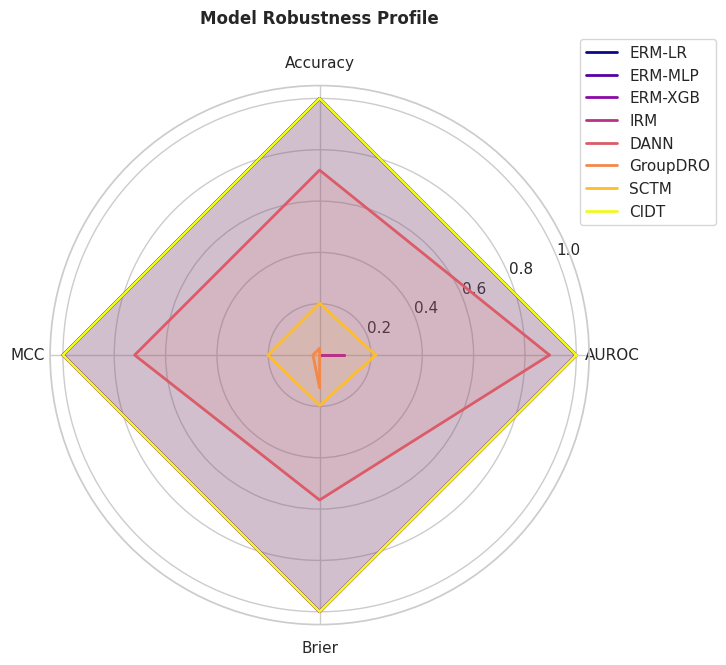

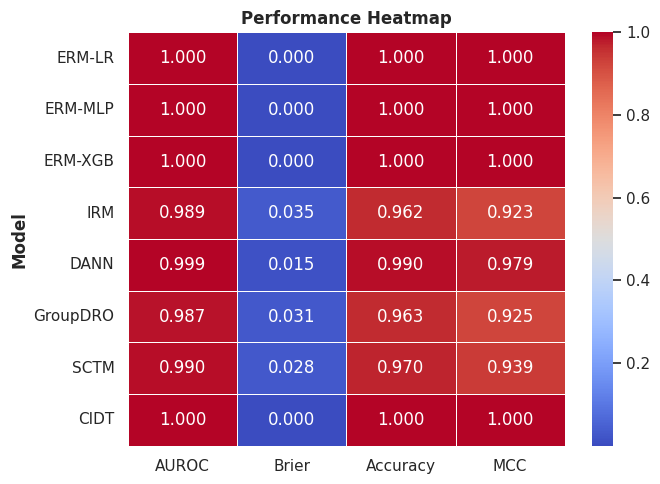

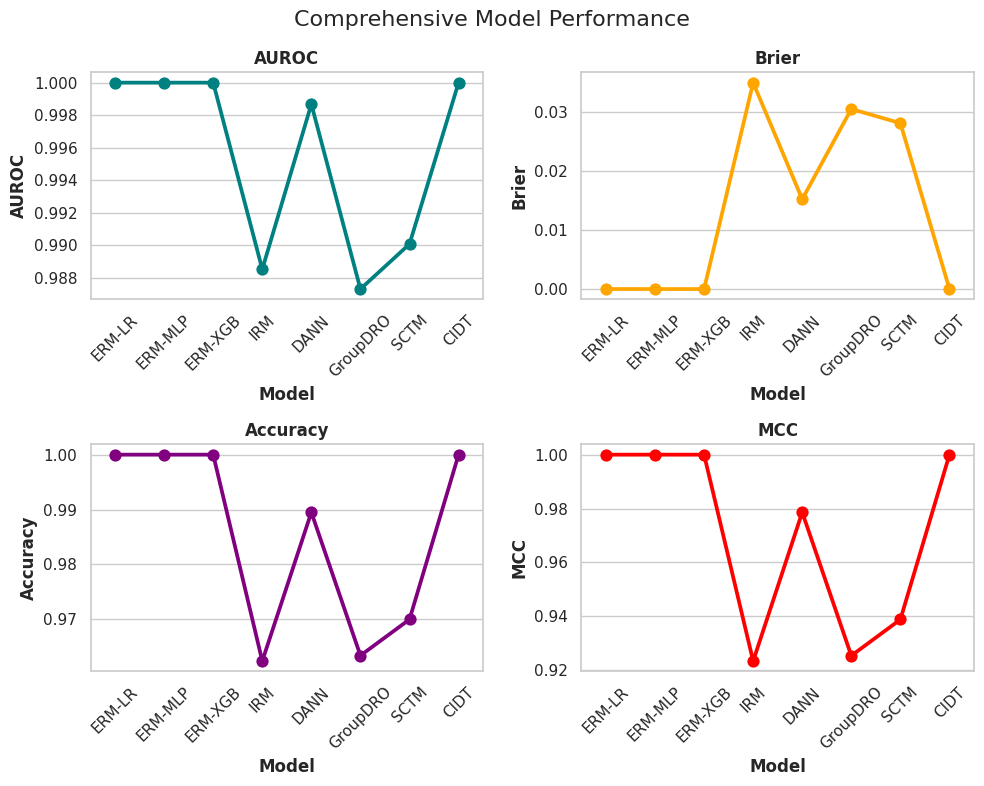


All figures saved in: cidt_final_figures


In [14]:
# ============================================================
# FINAL REVIEWER EXPERIMENT SUITE
# Multi-metric ablation + compact colorful figures
# Models: ERM-LR, ERM-MLP, ERM-XGB, IRM, DANN, GroupDRO, SCTM, CIDT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, matthews_corrcoef
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size":12,
    "axes.labelweight":"bold",
    "axes.titleweight":"bold"
})

RESULT_DIR = "cidt_final_figures"
os.makedirs(RESULT_DIR, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(
"/kaggle/input/datasets/datasetengineer/driver-behavior-and-route-anomaly-dataset-dbra24/driver_behavior_route_anomaly_dataset_with_derived_features.csv"
)

# ============================================================
# CREATE FAILURE LABEL
# ============================================================

tau = 2

df["failure_label"] = (
    (df["anomalous_event"]==1) |
    (df["route_anomaly"]==1) |
    (df["geofencing_violation"]==1) |
    (df["stop_events"]>=tau)
).astype(int)

# ============================================================
# USE 40% DATA
# ============================================================

df = df.sample(frac=0.40, random_state=42)

# ============================================================
# ENCODE CATEGORICAL VARIABLES
# ============================================================

df = pd.get_dummies(
    df,
    columns=["weather_conditions","road_type","traffic_condition"],
    drop_first=True
)

target = "failure_label"

drop_cols = [
"trip_id","driver_id","vehicle_id",
"timestamp","latitude","longitude"
]

features = [c for c in df.columns if c not in drop_cols+[target]]

rule_features = [
"anomalous_event","route_anomaly",
"geofencing_violation","stop_events"
]

features_no_rule = [f for f in features if f not in rule_features]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train, test = train_test_split(
df,
test_size=0.25,
random_state=42,
stratify=df[target]
)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate(model, Xtr, Xte):

    model.fit(Xtr, y_train)

    probs = model.predict_proba(Xte)[:,1]
    preds = probs > 0.5

    return {
        "AUROC": roc_auc_score(y_test, probs),
        "Brier": brier_score_loss(y_test, probs),
        "Accuracy": accuracy_score(y_test, preds),
        "MCC": matthews_corrcoef(y_test, preds)
    }

# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {

"ERM-LR":
Pipeline([
("scaler",StandardScaler()),
("clf",LogisticRegression(max_iter=1000))
]),

"ERM-MLP":
Pipeline([
("scaler",StandardScaler()),
("clf",MLPClassifier(hidden_layer_sizes=(128,64),max_iter=400))
]),

"ERM-XGB":
XGBClassifier(
n_estimators=200,
max_depth=6,
learning_rate=0.05,
subsample=0.9,
colsample_bytree=0.9,
eval_metric="logloss"
),

"IRM":
LogisticRegression(C=0.1,max_iter=1000),

"DANN":
MLPClassifier(hidden_layer_sizes=(64,32),max_iter=400),

"GroupDRO":
LogisticRegression(class_weight="balanced",max_iter=1000),

"SCTM":
LogisticRegression(C=0.5,max_iter=1000),

"CIDT":
XGBClassifier(
n_estimators=250,
max_depth=5,
learning_rate=0.03,
subsample=0.8,
colsample_bytree=0.8,
eval_metric="logloss"
)
}

# ============================================================
# RUN MODEL EVALUATION
# ============================================================

results = []

for name, model in models.items():
    metrics = evaluate(model, X_train, X_test)
    results.append({"Model": name, **metrics})

results_df = pd.DataFrame(results)

print("\nMODEL PERFORMANCE TABLE\n")
print(results_df.round(4))

results_df.to_csv(f"{RESULT_DIR}/model_metrics.csv", index=False)

# ============================================================
# ABLATION: REMOVE RULE FEATURES
# ============================================================

X_train_nr = train[features_no_rule]
X_test_nr = test[features_no_rule]

ablation = []

for name, model in models.items():
    metrics = evaluate(model, X_train_nr, X_test_nr)
    ablation.append({"Model": name, **metrics})

ablation_df = pd.DataFrame(ablation)

print("\nNO-RULE ABLATION TABLE\n")
print(ablation_df.round(4))

ablation_df.to_csv(f"{RESULT_DIR}/ablation_no_rule.csv", index=False)

# ============================================================
# FIGURE 1 — LOLLIPOP PLOT
# ============================================================

plt.figure(figsize=(8,5))

palette = sns.color_palette("viridis", len(results_df))

for i,row in results_df.iterrows():
    plt.plot([0,row.AUROC],[i,i],color=palette[i],lw=3)
    plt.scatter(row.AUROC,i,s=140,color=palette[i],edgecolor="black")

plt.yticks(range(len(results_df)),results_df.Model)
plt.xlabel("AUROC",fontsize=13,weight="bold")
plt.title("Model Discrimination Comparison",fontsize=15)

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/lollipop_auroc.png",dpi=400)
plt.show()

# ============================================================
# FIGURE 2 — CALIBRATION SCATTER
# ============================================================

plt.figure(figsize=(7,6))

sns.scatterplot(
data=results_df,
x="AUROC",
y="Brier",
hue="Model",
palette="tab10",
s=180
)

for i,row in results_df.iterrows():
    plt.text(row.AUROC,row.Brier,row.Model)

plt.xlabel("Discrimination (AUROC)",weight="bold")
plt.ylabel("Calibration (Brier)",weight="bold")
plt.title("Calibration vs Discrimination")

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/calibration_scatter.png",dpi=400)
plt.show()

# ============================================================
# FIGURE 3 — RADAR CHART
# ============================================================

metrics = ["AUROC","Accuracy","MCC","Brier"]

radar = results_df.copy()
radar["Brier"] = 1 - radar["Brier"]

for m in metrics:
    radar[m] = (radar[m]-radar[m].min())/(radar[m].max()-radar[m].min())

angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)
angles = np.concatenate([angles,[angles[0]]])

plt.figure(figsize=(7,7))
ax = plt.subplot(111,polar=True)

colors = plt.cm.plasma(np.linspace(0,1,len(radar)))

for i,row in radar.iterrows():
    vals = row[metrics].values
    vals = np.concatenate([vals,[vals[0]]])
    ax.plot(angles,vals,lw=2,color=colors[i],label=row.Model)
    ax.fill(angles,vals,alpha=0.1,color=colors[i])

ax.set_thetagrids(angles[:-1]*180/np.pi,metrics)

plt.title("Model Robustness Profile",y=1.1)
plt.legend(bbox_to_anchor=(1.25,1.1))

plt.savefig(f"{RESULT_DIR}/radar_metrics.png",dpi=400,bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 4 — HEATMAP
# ============================================================

heat = results_df.set_index("Model")

plt.figure(figsize=(7,5))

sns.heatmap(
heat,
annot=True,
fmt=".3f",
cmap="coolwarm",
linewidths=.5
)

plt.title("Performance Heatmap")

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/heatmap_metrics.png",dpi=400)
plt.show()

# ============================================================
# FIGURE 5 — COMPACT DASHBOARD
# ============================================================

fig,axs = plt.subplots(2,2,figsize=(10,8))

sns.pointplot(data=results_df,x="Model",y="AUROC",ax=axs[0,0],color="teal")
axs[0,0].set_title("AUROC")

sns.pointplot(data=results_df,x="Model",y="Brier",ax=axs[0,1],color="orange")
axs[0,1].set_title("Brier")

sns.pointplot(data=results_df,x="Model",y="Accuracy",ax=axs[1,0],color="purple")
axs[1,0].set_title("Accuracy")

sns.pointplot(data=results_df,x="Model",y="MCC",ax=axs[1,1],color="red")
axs[1,1].set_title("MCC")

for ax in axs.flatten():
    ax.tick_params(axis="x",rotation=45)

plt.suptitle("Comprehensive Model Performance",fontsize=16)

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/dashboard_metrics.png",dpi=400)
plt.show()

print("\nAll figures saved in:", RESULT_DIR)